[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/HumbertoDiego/AjustamentoAvancadoIME/blob/main/04_series_temporais.ipynb)

# Aula 4 — Séries Temporais

**Maj Diego - 1º Semestre / 2027**

**Objetivos:**

1. Decompor uma série em tendência, sazonalidade e ruído.
2. Construir um modelo linear harmônico.
3. Diagnosticar resíduos temporais e preparar a 3ª VE prática.

## 1. Componentes

Uma série pode ser representada por $y_t=T_t+S_t+e_t$: tendência $T_t$, sazonalidade $S_t$ e ruído $e_t$. Em dados geodésicos, descontinuidades e correlação temporal exigem atenção especial.

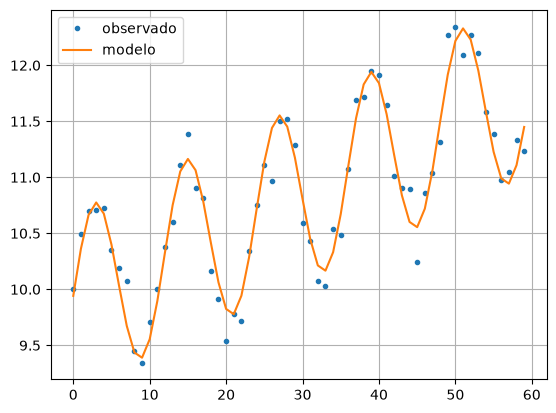

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)
t = np.arange(60)
y = 10 + 0.03*t + 0.8*np.sin(2*np.pi*t/12) + rng.normal(0, .2, len(t))
A = np.column_stack([np.ones_like(t), t, np.sin(2*np.pi*t/12), np.cos(2*np.pi*t/12)])
beta = np.linalg.lstsq(A, y, rcond=None)[0]
y_hat = A @ beta
plt.plot(t, y, '.', label='observado'); plt.plot(t, y_hat, label='modelo'); plt.legend(); plt.grid();

## 2. Modelagem

A matriz de projeto reúne intercepto, tendência e termos harmônicos. Frequência, fase e amplitude devem ter interpretação física. Inspecione resíduos, autocorrelação, mudanças de regime e observações faltantes.

In [2]:
residuos = y_hat - y
print('Parâmetros:', beta)
print('RMSE:', np.sqrt(np.mean(residuos**2)))
print('Correlação lag 1:', np.corrcoef(residuos[:-1], residuos[1:])[0,1])

Parâmetros: [9.88821847 0.0323699  0.79000033 0.05338731]
RMSE: 0.16727318778661118
Correlação lag 1: -0.10133054316161043


## 3ª VE prática

Modelar uma série geodésica, separar tendência e sazonalidade, avaliar resíduos e interpretar a taxa estimada. Entregar notebook, gráfico, parâmetros com unidades e discussão de limitações.